In [1]:
import json
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List, Sequence, Callable
from __future__ import annotations

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random

In [2]:
# ============================================================
# Configuration:
#   -   Cut period to remove initialization bias
#   -   Remove failed operations from analysis
# ============================================================

# Cut period in seconds - operations in the first N seconds will be excluded
CUT_PERIOD_SECONDS = 10.0

def apply_cut_period(df: pd.DataFrame, cut_seconds: float = CUT_PERIOD_SECONDS) -> pd.DataFrame:
    """
    Filter out operations that started within the first cut_seconds of the run.
    This removes initialization bias from the analysis.
    """
    if len(df) == 0 or cut_seconds <= 0:
        return df
    
    t0 = df["ts_start"].min()
    cutoff_time = t0 + pd.Timedelta(seconds=cut_seconds)
    
    mask = df["ts_start"] >= cutoff_time
    return df[mask].copy()

def remove_failed_operations(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove operations that failed (status != "success") from the analysis.
    This focuses the analysis on successful operations only.
    """
    if len(df) == 0:
        return df
    
    df = df[df["success"] == True].copy()

    return df


In [3]:
# ============================================================
# Import a dataframe from a CSV file and preprocess it for analysis.
# ============================================================

def load_summary(file_path: str) -> pd.DataFrame:
    # Load the data from the CSV file
    df = pd.read_csv(file_path)

    # Basic validation
    required = {"ts_start", "ts_end", "success", "latency_ms"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{file_path} missing columns: {missing}")

    # Change the ts_start and ts_end columns to datetime format
    df['ts_start'] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
    df['ts_end'] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")

    return df

def load_events(file_path: str) -> pd.DataFrame:
    # Load the data from the JSONL file
    df = pd.read_json(file_path, lines=True)

    # Basic validation
    required = {"phase", "nodeId", "reqId"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{file_path} missing columns: {missing}")

    # Change the ts column to datetime format
    df['ts'] = pd.to_datetime(df["ts"], utc=True, errors="coerce")

    # Change the nodeId from "15" to "node_15"
    df['nodeId'] = df['nodeId'].apply(lambda x: f"node_{x}" if isinstance(x, int) else x)

    return df

In [4]:
import json
from dataclasses import dataclass
from datetime import datetime, timezone
from collections import defaultdict
import re
from typing import List, Tuple, Optional

"""
Sequential Consistency Checker for Distributed Storage System

This checker validates Sequential Consistency (SC), NOT Linearizability.

Key difference:
- Linearizability: Must respect real-time ordering (timestamps)
- Sequential Consistency: Only requires a valid total ordering that preserves
  per-client program order, regardless of wall-clock time

Example: If client A writes x=1 at t=1.0 and client B reads x=0 at t=2.0,
  Linearizability: VIOLATION (B must see A's write)
  Sequential Consistency: OK (can order as: Read-B → Write-A)

Checks performed:
1. Read-your-writes: Each client must see its own writes
2. Monotonic reads: Same client can't see older versions after newer ones
3. No impossible reads: Can't read versions that were never written
4. Version consistency: No missing version numbers (lost updates)
"""


# --------- parsing helpers ---------

REQID_RE = re.compile(r"^(?P<client>\d+)-(?P<seq>\d+)$")

def parse_ts_iso_z(s: str) -> int:
    """
    Parse timestamps like: 2026-01-22T18:02:31.615350400Z
    Return integer nanoseconds since epoch (best-effort).
    Python datetime supports microseconds; we'll keep microsecond precision.
    """
    # trim to microseconds to avoid ValueError (615350400 -> 615350)
    if s.endswith("Z"):
        s2 = s[:-1]
    else:
        s2 = s

    # split fractional seconds
    if "." in s2:
        base, frac = s2.split(".", 1)
        frac = (frac + "000000")[:6]  # microseconds
        s2 = f"{base}.{frac}"
    dt = datetime.fromisoformat(s2).replace(tzinfo=timezone.utc)
    # microsecond precision
    return int(dt.timestamp() * 1_000_000_000)


def parse_reqid(reqid: str) -> Optional[Tuple[int, int]]:
    """
    Return (client_id, seq_no) if format matches '10-2', else None
    """
    m = REQID_RE.match(reqid)
    if not m:
        return None
    return int(m.group("client")), int(m.group("seq"))


@dataclass(frozen=True)
class LogEvent:
    ts_ns: int
    node_id: int
    req_id: str
    op: str
    key: int
    version: int
    phase: str
    success: bool


def load_jsonl(path: str) -> List[LogEvent]:
    events = []
    with open(path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            events.append(LogEvent(
                ts_ns=parse_ts_iso_z(obj["ts"]),
                node_id=int(obj["nodeId"]),
                req_id=str(obj["reqId"]),
                op=str(obj["operation"]),
                key=int(obj["key"]),
                version=int(obj["version"]),
                phase=str(obj["phase"]),
                success=bool(obj["success"]),
            ))
    return events


# --------- Sequential Consistency checks (program-order based) ---------

def check_sequential_consistency(events: List[LogEvent], W: int = 2) -> List[str]:
    """
    Check necessary conditions for Sequential Consistency:
    
    Sequential Consistency requires there exists SOME total ordering where:
    1. Each client's operations appear in program order (by sequence number)
    2. Each read returns the value from the most recent write in that ordering
    
    Unlike linearizability, SC does NOT require respecting real-time ordering
    between different clients.
    
    We check necessary conditions:
    - Read-your-writes: If a client writes then reads, must see own write (or later)
    - Monotonic reads: Within same client, version numbers shouldn't go backwards
    - No impossible reads: Can't read a version that was never successfully written
    """
    errors = []

    # Build a mapping of successful operations per client
    # client -> list of (seq, op_type, key, version, req_id)
    client_ops = defaultdict(list)
    
    # Track all successfully written versions: key -> set of versions
    written_versions = defaultdict(set)
    
    # Collect all successful operations
    for e in events:
        if not e.success:
            continue
            
        if e.op == "UPDATE" and e.phase == "DEC_UPDATE_SUCCESS":
            parsed = parse_reqid(e.req_id)
            if parsed:
                client_id, seq = parsed
                client_ops[client_id].append((seq, "UPDATE", e.key, e.version, e.req_id))
                written_versions[e.key].add(e.version)
                
        elif e.op == "GET" and e.phase == "DEC_GET_SUCCESS":
            parsed = parse_reqid(e.req_id)
            if parsed:
                client_id, seq = parsed
                client_ops[client_id].append((seq, "GET", e.key, e.version, e.req_id))
    
    # Sort each client's operations by sequence number
    for client_id in client_ops:
        client_ops[client_id].sort(key=lambda x: x[0])
    
    # Check 1: Read-your-writes within each client
    for client_id, ops in client_ops.items():
        last_write_per_key = {}  # key -> (seq, version)
        
        for seq, op_type, key, version, req_id in ops:
            if op_type == "UPDATE":
                last_write_per_key[key] = (seq, version)
            elif op_type == "GET":
                # Check if this client previously wrote to this key
                if key in last_write_per_key:
                    write_seq, write_version = last_write_per_key[key]
                    # Read comes after write in program order
                    if seq > write_seq and version < write_version:
                        errors.append(
                            f"[READ-YOUR-WRITES] client={client_id} wrote v={write_version} "
                            f"(seq={write_seq}) but later read v={version} (seq={seq}) for key={key}"
                        )
    
    # Check 2: Monotonic reads within each client
    for client_id, ops in client_ops.items():
        last_read_per_key = {}  # key -> (seq, version)
        
        for seq, op_type, key, version, req_id in ops:
            if op_type == "GET":
                if key in last_read_per_key:
                    prev_seq, prev_version = last_read_per_key[key]
                    if version < prev_version:
                        errors.append(
                            f"[MONOTONIC-READS] client={client_id} read v={prev_version} "
                            f"(seq={prev_seq}) but later read v={version} (seq={seq}) for key={key}"
                        )
                last_read_per_key[key] = (seq, version)
    
    # Check 3: No impossible reads (reading versions that were never written)
    for client_id, ops in client_ops.items():
        for seq, op_type, key, version, req_id in ops:
            if op_type == "GET" and version > 0:
                if version not in written_versions[key]:
                    errors.append(
                        f"[IMPOSSIBLE-READ] client={client_id} read v={version} for key={key} "
                        f"but that version was never successfully written"
                    )
    
    # Check 4: Version consistency - no gaps that violate causality
    # For each key, versions should be written in order (allowing for concurrent writes)
    for key, versions in written_versions.items():
        if not versions:
            continue
        max_version = max(versions)
        # Check if all versions from 1 to max exist
        for v in range(1, max_version + 1):
            if v not in versions:
                errors.append(
                    f"[MISSING-VERSION] key={key} has v={max_version} but v={v} was never written "
                    f"(possible lost update or coordinator inconsistency)"
                )

    return errors


def check_write_write_conflicts(events: List[LogEvent]) -> List[str]:
    """
    Detect Write-Write conflicts:
    - Multiple UPDATEs claiming the same version for a key (duplicate versions)
    - Overlapping UPDATEs that might cause lost updates
    
    For SC, we check:
    1. Duplicate versions: Same (key, version) written by different requests
    2. Version ordering: Ensure writes don't create inconsistent version sequences
    """
    errors = []
    
    # Track which request wrote which version: (key, version) -> list of req_ids
    version_writers = defaultdict(list)
    
    # Track UPDATE timing for overlap detection: req_id -> (key, version, start_ts, end_ts)
    update_timing = {}
    
    for e in events:
        if e.op == "UPDATE":
            if e.phase == "INT_UPDATE_START":
                if e.req_id not in update_timing:
                    update_timing[e.req_id] = {'key': e.key, 'start': e.ts_ns, 'end': None, 'version': None}
            elif e.phase == "DEC_UPDATE_SUCCESS" and e.success:
                if e.req_id in update_timing:
                    update_timing[e.req_id]['end'] = e.ts_ns
                    update_timing[e.req_id]['version'] = e.version
                version_writers[(e.key, e.version)].append(e.req_id)
    
    # Check 1: Duplicate versions (multiple requests wrote same version)
    for (key, version), req_ids in version_writers.items():
        if len(req_ids) > 1:
            errors.append(
                f"[WRITE-WRITE-CONFLICT] key={key} v={version} written by multiple requests: "
                f"{', '.join(req_ids)} (lost update or version collision)"
            )
    
    # Check 2: Overlapping writes that produced consecutive versions
    # Group updates by key
    # updates_by_key = defaultdict(list)
    # for req_id, info in update_timing.items():
    #     if info['end'] is not None and info['version'] is not None:
    #         updates_by_key[info['key']].append((info['start'], info['end'], info['version'], req_id))
    
    # for key, updates in updates_by_key.items():
    #     # Sort by version
    #     updates.sort(key=lambda x: x[2])
        
    #     # Check if consecutive version UPDATEs overlapped in time
    #     for i in range(len(updates) - 1):
    #         start1, end1, ver1, req1 = updates[i]
    #         start2, end2, ver2, req2 = updates[i + 1]
            
    #         # Check if they're consecutive versions
    #         if ver2 == ver1 + 1:
    #             # Check for temporal overlap: does req2 start before req1 ends?
    #             if start2 < end1:
    #                 errors.append(
    #                     f"[WRITE-WRITE-OVERLAP] key={key}: {req2} (v={ver2}) started before "
    #                     f"{req1} (v={ver1}) completed - potential race condition"
    #                 )
    
    return errors


def check_write_read_conflicts(events: List[LogEvent]) -> List[str]:
    """
    Detect Write-Read conflicts:
    - GETs that read during an overlapping UPDATE might see inconsistent state
    - Reads that happen during a write should either see old or new value, not partial
    
    For SC, we check if reads during concurrent writes see consistent versions.
    """
    errors = []
    
    # Track UPDATE windows: req_id -> (key, version, start_ts, end_ts)
    update_windows = {}
    for e in events:
        if e.op == "UPDATE":
            if e.phase == "INT_UPDATE_START":
                if e.req_id not in update_windows:
                    update_windows[e.req_id] = {'key': e.key, 'start': e.ts_ns, 'end': None, 'version': None}
            elif e.phase == "DEC_UPDATE_SUCCESS" and e.success:
                if e.req_id in update_windows:
                    update_windows[e.req_id]['end'] = e.ts_ns
                    update_windows[e.req_id]['version'] = e.version
    
    # Track GET timing: req_id -> (key, read_version, start_ts, end_ts)
    get_timing = {}
    for e in events:
        if e.op == "GET":
            if e.phase == "INT_GET_START":
                if e.req_id not in get_timing:
                    get_timing[e.req_id] = {'key': e.key, 'start': e.ts_ns, 'end': None, 'version': None}
            elif e.phase == "DEC_GET_SUCCESS" and e.success:
                if e.req_id in get_timing:
                    get_timing[e.req_id]['end'] = e.ts_ns
                    get_timing[e.req_id]['version'] = e.version
    
    # Check for overlapping READ during UPDATE
    for get_req, get_info in get_timing.items():
        if get_info['end'] is None or get_info['version'] is None:
            continue
            
        key = get_info['key']
        get_start = get_info['start']
        get_end = get_info['end']
        read_version = get_info['version']
        
        # Find all UPDATEs to same key that overlap with this GET
        overlapping_updates = []
        for upd_req, upd_info in update_windows.items():
            if upd_info['end'] is None or upd_info['version'] is None:
                continue
            if upd_info['key'] != key:
                continue
                
            # Check for temporal overlap
            # Overlap if: update_start < get_end AND get_start < update_end
            if upd_info['start'] < get_end and get_start < upd_info['end']:
                overlapping_updates.append((upd_req, upd_info['version']))
        
        # If GET overlapped with UPDATEs, check for consistency
        if overlapping_updates:
            # The read should be either:
            # - The version just before any overlapping update
            # - The version of one of the overlapping updates
            update_versions = [v for _, v in overlapping_updates]
            min_update_version = min(update_versions)
            max_update_version = max(update_versions)
            
            # Read is OK if it's (min-1) or within [min, max]
            expected_range = list(range(min_update_version - 1 if min_update_version > 0 else 0, 
                                       max_update_version + 1))
            
            if read_version not in expected_range:
                update_strs = [f"{req}(v={v})" for req, v in overlapping_updates]
                errors.append(
                    f"[WRITE-READ-CONFLICT] {get_req} read v={read_version} for key={key} "
                    f"during overlapping UPDATEs {', '.join(update_strs)} - "
                    f"expected v in {expected_range}"
                )
    
    return errors


def check_per_client_program_order(events: List[LogEvent]) -> List[str]:
    """
    If reqId encodes program order (client-seq), check that DEC events respect it:
    For each client, seq numbers must appear in nondecreasing order in DEC_*_SUCCESS events.
    This is not required by SC unless you want to enforce client-issued order explicitly.
    """
    errors = []

    dec = [e for e in events if e.success and e.phase.startswith("DEC_") and e.op in ("UPDATE", "GET")]
    dec.sort(key=lambda e: (e.ts_ns, e.req_id, e.node_id))

    last_seq = {}  # client_id -> last_seq_seen
    for e in dec:
        parsed = parse_reqid(e.req_id)
        if not parsed:
            continue
        client, seq = parsed
        prev = last_seq.get(client)
        if prev is not None and seq < prev:
            errors.append(
                f"[PROG-ORDER] client={client} saw reqId={e.req_id} after seq={prev} "
                f"(timestamp order violates client program order assumption)"
            )
        last_seq[client] = max(prev, seq) if prev is not None else seq

    return errors


def run_all_checks(path: str) -> int:
    events = load_jsonl(path)

    errors = []
    errors += check_sequential_consistency(events)
    errors += check_write_write_conflicts(events)
    errors += check_write_read_conflicts(events)

    # if not errors:
    #     print("✅ Sequential Consistency checks passed!")
    #     print("   - Read-your-writes: OK")
    #     print("   - Monotonic reads: OK")
    #     print("   - No impossible reads: OK")
    #     print("   - Version consistency: OK")
    #     print("   - Write-write conflicts: OK")
    #     print("   - Write-read conflicts: OK")
    #     return 0

    # print("❌ Sequential Consistency violations found:")
    
    # Group errors by type for better readability
    sc_errors = [e for e in errors if any(t in e for t in ["READ-YOUR-WRITES", "MONOTONIC-READS", "IMPOSSIBLE-READ", "MISSING-VERSION"])]
    ww_errors = [e for e in errors if "WRITE-WRITE" in e]
    wr_errors = [e for e in errors if "WRITE-READ" in e]
    
    # if sc_errors:
    #     print("\n  📋 Basic SC violations:")
    #     for err in sc_errors:
    #         print("    -", err)
    
    # if ww_errors:
    #     print("\n  ⚠️  Write-Write conflicts:")
    #     for err in ww_errors:
    #         print("    -", err)
    #     print("\n     Note: WRITE-WRITE-OVERLAP means concurrent UPDATEs from different coordinators")
    #     # print("           raced. This is OK for SC if replica-level locking prevents actual conflicts.")
    
    # if wr_errors:
    #     print("\n  ⚠️  Write-Read conflicts:")
    #     for err in wr_errors:
    #         print("    -", err)
    #     print("\n     Note: WRITE-READ-CONFLICT means a GET read during a concurrent UPDATE.")
        # print("           This is OK for SC if the read saw a consistent version.")
    
    print(f"\n  Total violations: {len(errors)}")
    return 1


# if __name__ == "__main__":
#     # change this to your file name
#     exit(run_all_checks("events copy 2.jsonl"))


In [5]:
for folder in Path("BalancedR2W2").iterdir():
    for file in folder.glob("*.jsonl"):
        print(f"Processing {file}")
        run_all_checks(file)

Processing BalancedR2W2/2026-02-27T19-58-08.369922_runTag=quorumTradeOffR2W2Balanced/events.jsonl

  Total violations: 0
Processing BalancedR2W2/2026-02-27T20-03-09.664654700_runTag=quorumTradeOffR2W2Balanced/events.jsonl

  Total violations: 0
Processing BalancedR2W2/2026-02-27T20-08-10.618628800_runTag=quorumTradeOffR2W2Balanced/events.jsonl

  Total violations: 0
Processing BalancedR2W2/2026-02-27T20-13-11.583105500_runTag=quorumTradeOffR2W2Balanced/events.jsonl

  Total violations: 1
Processing BalancedR2W2/2026-02-27T20-18-12.543249400_runTag=quorumTradeOffR2W2Balanced/events.jsonl

  Total violations: 1
Processing BalancedR2W2/2026-02-27T20-23-13.504851200_runTag=quorumTradeOffR2W2Balanced/events.jsonl

  Total violations: 1
Processing BalancedR2W2/2026-02-27T20-28-14.466572100_runTag=quorumTradeOffR2W2Balanced/events.jsonl

  Total violations: 0
Processing BalancedR2W2/2026-02-27T20-33-15.429393500_runTag=quorumTradeOffR2W2Balanced/events.jsonl

  Total violations: 0
Processing 

In [7]:
# ============================================================
# Given summary and events return summary with reason of failure for failed operations.
# ============================================================

DEC_PREFIX = "DEC_"

def classify_from_phase(phase: str, op: str) -> Optional[str]:
    """
    Map DEC event phase to failure cause.
    Returns one of: TIMEOUT, UNAVAILABLE, SUCCESS, None
    """
    if not phase:
        return None
    p = str(phase).strip().upper()

    # We only care about DEC events
    if not p.startswith(DEC_PREFIX):
        return None

    # Examples: DEC_GET_TIMEOUT, DEC_UPDATE_FAIL, DEC_GET_SUCCESS ...
    if op == "GET":
        if p == "DEC_GET_TIMEOUT":
            return "TIMEOUT"
        if p == "DEC_GET_FAIL":
            return "UNAVAILABLE"
        if p == "DEC_GET_SUCCESS":
            return "SUCCESS"
    elif op == "UPDATE":
        if p == "DEC_UPDATE_TIMEOUT":
            return "TIMEOUT"
        if p == "DEC_UPDATE_FAIL":
            return "UNAVAILABLE"
        if p == "DEC_UPDATE_SUCCESS":
            return "SUCCESS"

    # If you ever add other DEC_* phases, you can extend here
    return None

def enrich_summary_with_failure_reasons(summary: pd.DataFrame, events: pd.DataFrame) -> pd.DataFrame:
    """
    Enrich summary with failure reasons from events.
    Events use: nodeId (converted to "node_XX"), reqId
    Summary uses: node_id, req_id, op
    """
    # Filter events to only include DEC_ events
    dec_events = events[events["phase"].str.startswith(DEC_PREFIX, na=False)].copy()
    
    # Create a mapping of (nodeId, reqId) -> op from summary
    # Summary columns: node_id, req_id, op
    op_map = summary.set_index(["node_id", "req_id"])["op"].to_dict()
    
    # Classify each event using the phase and corresponding op
    def get_reason(row):
        # Events already have nodeId converted to "node_XX" format by load_events
        op = op_map.get((row["nodeId"], row["reqId"]))
        if op:
            return classify_from_phase(row["phase"], op)
        return None
    
    dec_events["reason"] = dec_events.apply(get_reason, axis=1)
    
    # Create a mapping of (nodeId, reqId) to reason (only keep non-None reasons)
    reason_map = dec_events[dec_events["reason"].notna()].set_index(["nodeId", "reqId"])["reason"].to_dict()
    
    # Create a new column in the summary for the failure reason
    # If not found in DEC_ events (i.e., INT_ events), assign "REJECTED"
    summary["failure_reason"] = summary.apply(
        lambda row: reason_map.get((row["node_id"], row["req_id"]), "REJECTED") if not row["success"] else None,
        axis=1
    )
    
    return summary


In [8]:

# ============================================================
# 2) Run-level (per-run) estimators
#    Each returns ONE number per run
# ============================================================

def run_mean_latency_ms(df: pd.DataFrame) -> float:
    """Mean latency in ms for this run."""
    return float(df["latency_ms"].astype(float).mean())


def run_quantile_latency_ms(df: pd.DataFrame, q: float) -> float:
    """Latency quantile (e.g. q=0.5 for median, 0.9, 0.99) for this run."""
    return float(df["latency_ms"].astype(float).quantile(q))


def run_throughput_ops_per_s(df: pd.DataFrame) -> float:
    """
    Throughput = completed ops / elapsed seconds in the run window.
    Uses ts_start min and ts_end max.
    """

    t0 = df["ts_start"].min()
    t1 = df["ts_end"].max()
    elapsed_s = (t1 - t0).total_seconds()

    if elapsed_s <= 0:
        return float("nan")

    return float(len(df) / elapsed_s)

def run_failure_rate(df: pd.DataFrame) -> float:
    """Failure rate = (# failed ops) / (# total ops) in this run."""
    total = len(df)
    if total == 0:
        return float("nan")
    fails = int((df["success"] == False).sum())
    return float(fails / total)

def run_failure_rate_update(df: pd.DataFrame) -> float:
    """Failure rate for update operations only."""
    updates = df[df["op"] == "UPDATE"]
    total = len(updates)
    if total == 0:
        return float("nan")
    fails = int((updates["success"] == False).sum())
    return float(fails / total)

def run_failure_rate_read(df: pd.DataFrame) -> float:
    """Failure rate for read operations only."""
    reads = df[df["op"] == "GET"]
    total = len(reads)
    if total == 0:
        return float("nan")
    fails = int((reads["success"] == False).sum())
    return float(fails / total)

def run_request_per_node(df: pd.DataFrame) -> np.array:
    """Number of requests per node"""
    return df.groupby("node_id")["op"].count().values

def run_request_per_key(df: pd.DataFrame) -> np.array:
    """Number of requests per key"""
    return df.groupby("key")["op"].count().values

def run_failure_rate_per_reason(df: pd.DataFrame) -> Dict[str, float]:
    """
    Failure rate broken down by failure reason (e.g. TIMEOUT, UNAVAILABLE, REJECTED).
    Returns the percentage of total operations that failed with each reason.
    """
    total_ops = len(df)
    if total_ops == 0:
        return {}
    
    # Count failures by reason
    failure_counts = df[df["failure_reason"].notna()]["failure_reason"].value_counts()
    
    # Convert to rates (percentage of total operations)
    rates = {}
    for reason, count in failure_counts.items():
        rates[reason] = float(count / total_ops)
    
    rates["SUCCESS"] = float((df["success"] == True).sum() / total_ops)
    
    return rates

def run_failure_count_per_reason(df: pd.DataFrame) -> Dict[str, int]:
    """
    Count of failures by reason (e.g. TIMEOUT, UNAVAILABLE, REJECTED).
    """
    # Count failures by reason
    failure_counts = df[df["failure_reason"].notna()]["failure_reason"].value_counts()
    failure_counts["SUCCESS"] = (df["success"] == True).sum()
    return failure_counts.to_dict()


In [9]:
# ============================================================
# 3) Confidence intervals across runs
# ============================================================

def t_critical_95(df: int) -> float:
    """
    95% two-sided t critical values for small df (1..30).
    Enough for b=10/20/30.
    If df is larger, we approximate with 1.96.
    """
    table = {
        1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571,
        6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262, 10: 2.228,
        11: 2.201, 12: 2.179, 13: 2.160, 14: 2.145, 15: 2.131,
        16: 2.120, 17: 2.110, 18: 2.101, 19: 2.093, 20: 2.086,
        21: 2.080, 22: 2.074, 23: 2.069, 24: 2.064, 25: 2.060,
        26: 2.056, 27: 2.052, 28: 2.048, 29: 2.045, 30: 2.042
    }
    return table.get(df, 1.96)

def ci_mean_t(values: Sequence[float], confidence: float = 0.95) -> Tuple[float, float, float]:
    """
    Student-t CI for the mean of run-level values.
    Returns (mean, lo, hi).
    """
    xs = [float(x) for x in values if not math.isnan(float(x))]
    n = len(xs)
    if n < 2:
        return (float("nan"), float("nan"), float("nan"))

    mean = sum(xs) / n
    # sample standard deviation (unbiased)
    var = sum((x - mean) ** 2 for x in xs) / (n - 1)
    s = math.sqrt(var)
    se = s / math.sqrt(n)

    # We keep it simple: assume 95% by default
    if abs(confidence - 0.95) > 1e-9:
        raise ValueError("This simple helper supports only 95% CI. Extend if needed.")
    tcrit = t_critical_95(n - 1)

    lo = mean - tcrit * se
    hi = mean + tcrit * se
    return (mean, lo, hi)


def bootstrap_ci_stat(
    values: Sequence[float],
    stat_fn: Callable[[List[float]], float],
    confidence: float = 0.95,
    n_boot: int = 5000,
    seed: int = 0,
) -> Tuple[float, float, float]:
    """
    Bootstrap percentile CI for a statistic over run-level values.
    Returns (point_estimate, lo, hi).

    IMPORTANT: values here should be run-level statistics (e.g., 10 medians),
    not per-operation samples.
    """
    xs = [float(x) for x in values if not math.isnan(float(x))]
    n = len(xs)
    if n == 0:
        return (float("nan"), float("nan"), float("nan"))

    rng = random.Random(seed)

    point = stat_fn(xs)

    boot_stats = []
    for _ in range(n_boot):
        sample = [xs[rng.randrange(n)] for _ in range(n)]
        boot_stats.append(stat_fn(sample))

    boot_stats.sort()

    alpha = 1.0 - confidence
    lo_idx = int(math.floor((alpha / 2) * n_boot))
    hi_idx = int(math.ceil((1 - alpha / 2) * n_boot)) - 1
    lo = boot_stats[max(0, min(lo_idx, n_boot - 1))]
    hi = boot_stats[max(0, min(hi_idx, n_boot - 1))]

    return (point, lo, hi)

def median_stat(xs: List[float]) -> float:
    """Median of a list (no numpy)."""
    ys = sorted(xs)
    n = len(ys)
    mid = n // 2
    if n % 2 == 1:
        return float(ys[mid])
    return float((ys[mid - 1] + ys[mid]) / 2)


def quantile_stat(q: float) -> Callable[[List[float]], float]:
    """
    Return a stat function that computes a quantile of a list via
    simple linear interpolation between sorted points.
    """
    def _q(xs: List[float]) -> float:
        ys = sorted(xs)
        n = len(ys)
        if n == 1:
            return float(ys[0])
        # position in [0, n-1]
        pos = q * (n - 1)
        lo = int(math.floor(pos))
        hi = int(math.ceil(pos))
        if lo == hi:
            return float(ys[lo])
        w = pos - lo
        return float(ys[lo] * (1 - w) + ys[hi] * w)
    return _q

In [ ]:
def count_write_conflicts_per_subfolder(parent_dir: Path) -> Dict[str, float]:
    """
    For each subfolder in parent_dir, count write-write conflicts across all runs
    and compute the mean.
    Returns a dictionary mapping subfolder name -> mean conflict count.
    """
    subfolder_means = {}
    
    for subfolder in parent_dir.iterdir():
        if subfolder.is_dir():
            conflict_counts = {}
            
            # Iterate through runs in this subfolder
            for run_folder in subfolder.iterdir():
                if run_folder.is_dir():
                    events_file = run_folder / "events.jsonl"
                    if events_file.exists():
                        events = load_jsonl(str(events_file))
                        errors = check_write_write_conflicts(events)
                        # Count only WRITE-WRITE-CONFLICT errors
                        ww_count = sum(1 for e in errors if "WRITE-WRITE-CONFLICT" in e)
                        conflict_counts[run_folder.name] = ww_count
            
            # Compute mean for this subfolder
            if conflict_counts:
                mean = sum(conflict_counts.values()) / len(conflict_counts)
                subfolder_means[subfolder.name] = mean
    
    return subfolder_means

def compute_write_conflicts_with_ci(parent_dir: Path) -> Dict[str, Tuple[float, float, float]]:
    """
    For each subfolder, compute mean write-write conflicts with 95% CI.
    Returns a dictionary mapping subfolder name -> (mean, ci_lo, ci_hi).
    """
    subfolder_stats = {}
    
    for subfolder in parent_dir.iterdir():
        if subfolder.is_dir():
            conflict_counts = []
            
            # Iterate through runs in this subfolder
            for run_folder in subfolder.iterdir():
                if run_folder.is_dir():
                    events_file = run_folder / "events.jsonl"
                    if events_file.exists():
                        events = load_jsonl(str(events_file))
                        errors = check_write_write_conflicts(events)
                        # Count only WRITE-WRITE-CONFLICT errors
                        ww_count = sum(1 for e in errors if "WRITE-WRITE-CONFLICT" in e)
                        conflict_counts.append(float(ww_count))
            
            # Compute mean and CI using t-distribution
            if conflict_counts:
                mean, ci_lo, ci_hi = ci_mean_t(conflict_counts)
                
                # Also count total write operations across runs for this subfolder
                total_writes = []
                for run_folder in subfolder.iterdir():
                    if run_folder.is_dir():
                        summary_file = run_folder / "summary.csv"
                        if summary_file.exists():
                            df = load_summary(str(summary_file))
                            df = apply_cut_period(df)
                            write_count = len(df[df["op"] == "UPDATE"])
                            total_writes.append(write_count)
                
                # Compute conflict rate per run
                conflict_rates = []
                for i, conflict_count in enumerate(conflict_counts):
                    if i < len(total_writes) and total_writes[i] > 0:
                        rate = (conflict_count / total_writes[i]) * 100
                        conflict_rates.append(rate)
                
                # Compute mean and CI for conflict rate
                if conflict_rates:
                    rate_mean, rate_lo, rate_hi = ci_mean_t(conflict_rates)
                    print(f"  Conflict rate: {rate_mean:.2f}% [{rate_lo:.2f}%, {rate_hi:.2f}%]")
                    # Store in tuple as well
                    subfolder_stats[f"{subfolder.name}_rate"] = (rate_mean, rate_lo, rate_hi)
                
                # Also compute mean total writes for reference
                if total_writes:
                    mean_writes = sum(total_writes) / len(total_writes)
                    print(f"  Mean writes per run: {mean_writes:.0f}")
                subfolder_stats[subfolder.name] = (mean, ci_lo, ci_hi)
                print(f"{subfolder.name}: mean={mean:.2f}, 95%CI=[{ci_lo:.2f}, {ci_hi:.2f}]")
    
    return subfolder_stats

# Example usage:
# parent_dir = Path("./")
# write_conflict_stats = compute_write_conflicts_with_ci(parent_dir)
# print(f"\nWrite-Write Conflict Statistics across subfolders:")
# for subfolder, (mean, lo, hi) in write_conflict_stats.items():
#     print(f"  {subfolder}: {mean:.2f} [{lo:.2f}, {hi:.2f}]")

  Conflict rate: 0.00% [0.00%, 0.00%]
  Mean writes per run: 2624
BalancedR1W3: mean=0.00, 95%CI=[0.00, 0.00]
  Conflict rate: 0.01% [0.00%, 0.03%]
  Mean writes per run: 2795
BalancedR2W2: mean=0.40, 95%CI=[0.03, 0.77]
  Conflict rate: 0.98% [0.85%, 1.11%]
  Mean writes per run: 2794
BalancedR3W1: mean=27.40, 95%CI=[23.51, 31.29]
  Conflict rate: 0.00% [0.00%, 0.00%]
  Mean writes per run: 1705
R1W3: mean=0.00, 95%CI=[0.00, 0.00]
  Conflict rate: 0.00% [0.00%, 0.00%]
  Mean writes per run: 1697
R2W2: mean=0.00, 95%CI=[0.00, 0.00]
  Conflict rate: 0.55% [0.39%, 0.71%]
  Mean writes per run: 1678
R3W1: mean=9.30, 95%CI=[6.56, 12.04]
  Conflict rate: 0.00% [0.00%, 0.00%]
  Mean writes per run: 3440
WriteR1W3: mean=0.00, 95%CI=[0.00, 0.00]
  Conflict rate: 0.01% [-0.00%, 0.02%]
  Mean writes per run: 3886
WriteR2W2: mean=0.40, 95%CI=[-0.10, 0.90]
  Conflict rate: 1.26% [1.12%, 1.40%]
  Mean writes per run: 3893
WriteR3W1: mean=49.00, 95%CI=[43.65, 54.35]

Write-Write Conflict Statistics a

In [ ]:
# ============================================================
# Compute statistics across runs and confidence intervals
# ============================================================
SUMMARY_NAME = "summary.csv"

def compute_stat_across_runs(
    data_dir: Path,
) -> Dict:
    """
    Compute statistics across runs and confidence intervals.
    Returns a dictionary of statistic name -> (point_estimate, ci_lo, ci_hi).
    """
    p50_r = []
    p50_w = []
    p95_r = []
    p95_w = []
    p99_r = []
    p99_w = []

    throughput = []
    throughput_r = []
    throughput_w = []

    success_rate = []
    timeout_rate = []
    busy_rate = []

    for folder in data_dir.iterdir():
        if folder.is_dir():
            df = load_summary(folder / SUMMARY_NAME)
            df = enrich_summary_with_failure_reasons(df, load_events(folder / "events.jsonl"))

            df = apply_cut_period(df)

            df_success = remove_failed_operations(df)

            # Now I compute run-level stats
            df_r = df_success[df_success["op"] == "GET"]
            df_w = df_success[df_success["op"] == "UPDATE"]

            p50_r.append(run_quantile_latency_ms(df_r, 0.5))
            p50_w.append(run_quantile_latency_ms(df_w, 0.5))
            p95_r.append(run_quantile_latency_ms(df_r, 0.95))
            p95_w.append(run_quantile_latency_ms(df_w, 0.95))
            p99_r.append(run_quantile_latency_ms(df_r, 0.99))
            p99_w.append(run_quantile_latency_ms(df_w, 0.99))

            throughput.append(run_throughput_ops_per_s(df_success))
            throughput_r.append(run_throughput_ops_per_s(df_r))
            throughput_w.append(run_throughput_ops_per_s(df_w))

            rates = run_failure_rate_per_reason(df)
            success_rate.append(rates.get("SUCCESS", 0))
            timeout_rate.append(rates.get("TIMEOUT", 0))
            busy_rate.append(rates.get("UNAVAILABLE", 0) + rates.get("REJECTED", 0))
    
    # Compute mean and CI for each metric
    summary_stats = {
        # Read latency percentiles
        "p50_read_ms": {
            "median": bootstrap_ci_stat(p50_r, median_stat)
        },
        "p95_read_ms": {
            "median": bootstrap_ci_stat(p95_r, median_stat)
        },
        "p99_read_ms": {
            "median": bootstrap_ci_stat(p99_r, median_stat)
        },
        
        # Write latency percentiles
        "p50_write_ms": {
            "median": bootstrap_ci_stat(p50_w, median_stat)
        },
        "p95_write_ms": {
            "median": bootstrap_ci_stat(p95_w, median_stat)
        },
        "p99_write_ms": {
            "median": bootstrap_ci_stat(p99_w, median_stat)
        },
        
        # Throughput metrics
        "throughput_ops_per_s": {
            "mean": ci_mean_t(throughput),
        },
        "throughput_read_ops_per_s": {
            "mean": ci_mean_t(throughput_r),
        },
        "throughput_write_ops_per_s": {
            "mean": ci_mean_t(throughput_w),
        },
        
        # Success and failure rates
        "success_rate": {
            "mean": ci_mean_t(success_rate),
        },
        "timeout_rate": {
            "mean": ci_mean_t(timeout_rate),
        },
        "busy_rate": {
            "mean": ci_mean_t(busy_rate),
        }
    }

    return summary_stats

In [15]:
BASE_DIR = Path("./")
SUMMARY_NAME = "summary.csv"

final_stats = {}

for folder in BASE_DIR.iterdir():
    if folder.is_dir():
        print(f"Processing {folder.name}...")
        stats = compute_stat_across_runs(Path(folder))
        final_stats[folder.name] = stats

Processing BalancedR1W3...
Processing BalancedR2W2...
Processing BalancedR3W1...
Processing R1W3...
Processing R2W2...
Processing R3W1...
Processing WriteR1W3...
Processing WriteR2W2...
Processing WriteR3W1...


In [16]:
# Print summaries from final_stats
def format_stat_with_ci(point: float, lo: float, hi: float) -> str:
    """Format a statistic with its CI as 'point [lo, hi]'"""
    return f"{point:.2f} [{lo:.2f}, {hi:.2f}]"

print("=" * 100)
print("FINAL STATISTICS SUMMARY")
print("=" * 100)

for config_name, stats in final_stats.items():
    print(f"\n{'=' * 100}")
    print(f"Configuration: {config_name}")
    print('=' * 100)
    
    for metric_name, estimators in stats.items():
        print(f"\n{metric_name}:")
        
        if "mean" in estimators:
            mean_point, mean_lo, mean_hi = estimators["mean"]
            print(f"  Mean:   {format_stat_with_ci(mean_point, mean_lo, mean_hi)}")
        
        if "median" in estimators:
            median_point, median_lo, median_hi = estimators["median"]
            print(f"  Median: {format_stat_with_ci(median_point, median_lo, median_hi)}")


FINAL STATISTICS SUMMARY

Configuration: BalancedR1W3

p50_read_ms:
  Median: 141.50 [140.00, 146.50]

p95_read_ms:
  Median: 209.07 [202.00, 211.07]

p99_read_ms:
  Median: 239.18 [233.06, 244.88]

p50_write_ms:
  Median: 187.50 [186.00, 192.00]

p95_write_ms:
  Median: 257.45 [249.00, 260.00]

p99_write_ms:
  Median: 282.68 [280.00, 294.00]

throughput_ops_per_s:
  Mean:   10.75 [10.60, 10.90]

throughput_read_ops_per_s:
  Mean:   6.82 [6.74, 6.89]

throughput_write_ops_per_s:
  Mean:   3.94 [3.83, 4.04]

success_rate:
  Mean:   0.63 [0.63, 0.64]

timeout_rate:
  Mean:   0.10 [0.09, 0.10]

busy_rate:
  Mean:   0.27 [0.26, 0.28]

Configuration: BalancedR2W2

p50_read_ms:
  Median: 168.00 [167.00, 169.00]

p95_read_ms:
  Median: 227.00 [224.10, 229.00]

p99_read_ms:
  Median: 256.35 [251.00, 259.72]

p50_write_ms:
  Median: 175.00 [171.00, 178.00]

p95_write_ms:
  Median: 234.50 [233.00, 237.50]

p99_write_ms:
  Median: 267.68 [266.00, 271.77]

throughput_ops_per_s:
  Mean:   17.13 [16

In [17]:
# Create a comparative DataFrame across all configurations
comparison_rows = []

for config_name, stats in final_stats.items():
    row = {"configuration": config_name}
    
    for metric_name, estimators in stats.items():
        if "mean" in estimators:
            mean_point, mean_lo, mean_hi = estimators["mean"]
            row[f"{metric_name}_mean"] = mean_point
            row[f"{metric_name}_mean_ci_lo"] = mean_lo
            row[f"{metric_name}_mean_ci_hi"] = mean_hi
        
        if "median" in estimators:
            median_point, median_lo, median_hi = estimators["median"]
            row[f"{metric_name}_median"] = median_point
            row[f"{metric_name}_median_ci_lo"] = median_lo
            row[f"{metric_name}_median_ci_hi"] = median_hi
    
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

print("\n" + "=" * 100)
print("COMPARATIVE STATISTICS TABLE")
print("=" * 100)
print(comparison_df.to_string(index=False))

# You can save it to CSV:
# comparison_df.to_csv("quorum_comparison.csv", index=False)



COMPARATIVE STATISTICS TABLE
configuration  p50_read_ms_median  p50_read_ms_median_ci_lo  p50_read_ms_median_ci_hi  p95_read_ms_median  p95_read_ms_median_ci_lo  p95_read_ms_median_ci_hi  p99_read_ms_median  p99_read_ms_median_ci_lo  p99_read_ms_median_ci_hi  p50_write_ms_median  p50_write_ms_median_ci_lo  p50_write_ms_median_ci_hi  p95_write_ms_median  p95_write_ms_median_ci_lo  p95_write_ms_median_ci_hi  p99_write_ms_median  p99_write_ms_median_ci_lo  p99_write_ms_median_ci_hi  throughput_ops_per_s_mean  throughput_ops_per_s_mean_ci_lo  throughput_ops_per_s_mean_ci_hi  throughput_read_ops_per_s_mean  throughput_read_ops_per_s_mean_ci_lo  throughput_read_ops_per_s_mean_ci_hi  throughput_write_ops_per_s_mean  throughput_write_ops_per_s_mean_ci_lo  throughput_write_ops_per_s_mean_ci_hi  success_rate_mean  success_rate_mean_ci_lo  success_rate_mean_ci_hi  timeout_rate_mean  timeout_rate_mean_ci_lo  timeout_rate_mean_ci_hi  busy_rate_mean  busy_rate_mean_ci_lo  busy_rate_mean_ci_hi
 Bala

In [ ]:
# # MORE READ PROMINENT

# DATA_DIR = Path("R2W2")

# p50_r = []
# p50_w = []
# p95_r = []
# p95_w = []
# p99_r = []
# p99_w = []

# throughput = []
# throughput_r = []
# throughput_w = []

# success_rate = []
# timeout_rate = []
# busy_rate = []


# for folder in DATA_DIR.iterdir():
#     if folder.is_dir():
#         df = load_summary(folder / SUMMARY_NAME)
#         df = enrich_summary_with_failure_reasons(df, load_events(folder / "events.jsonl"))

#         df = apply_cut_period(df)

#         df_success = remove_failed_operations(df)

#         # Now I compute run-level stats
#         df_r = df_success[df_success["op"] == "GET"]
#         df_w = df_success[df_success["op"] == "UPDATE"]

#         p50_r.append(run_quantile_latency_ms(df_r, 0.5))
#         p50_w.append(run_quantile_latency_ms(df_w, 0.5))
#         p95_r.append(run_quantile_latency_ms(df_r, 0.95))
#         p95_w.append(run_quantile_latency_ms(df_w, 0.95))
#         p99_r.append(run_quantile_latency_ms(df_r, 0.99))
#         p99_w.append(run_quantile_latency_ms(df_w, 0.99))

#         throughput.append(run_throughput_ops_per_s(df_success))
#         throughput_r.append(run_throughput_ops_per_s(df_r))
#         throughput_w.append(run_throughput_ops_per_s(df_w))

#         rates = run_failure_rate_per_reason(df)
#         success_rate.append(rates["SUCCESS"])
#         timeout_rate.append(rates["TIMEOUT"])
#         busy_rate.append(rates["UNAVAILABLE"] + rates["REJECTED"])

# # ============================================================
# # Compute summary statistics with confidence intervals
# # ============================================================

# # Helper to format results
# def format_stat_with_ci(point: float, lo: float, hi: float) -> str:
#     """Format a statistic with its CI as 'point [lo, hi]'"""
#     return f"{point:.2f} [{lo:.2f}, {hi:.2f}]"

# # Compute mean and CI for each metric
# summary_stats = {
#     # Read latency percentiles
#     "p50_read_ms": {
#         "median": bootstrap_ci_stat(p50_r, median_stat)
#     },
#     "p95_read_ms": {
#         "median": bootstrap_ci_stat(p95_r, median_stat)
#     },
#     "p99_read_ms": {
#         "median": bootstrap_ci_stat(p99_r, median_stat)
#     },
    
#     # Write latency percentiles
#     "p50_write_ms": {
#         "median": bootstrap_ci_stat(p50_w, median_stat)
#     },
#     "p95_write_ms": {
#         "median": bootstrap_ci_stat(p95_w, median_stat)
#     },
#     "p99_write_ms": {
#         "median": bootstrap_ci_stat(p99_w, median_stat)
#     },
    
#     # Throughput metrics
#     "throughput_ops_per_s": {
#         "mean": ci_mean_t(throughput),
#     },
#     "throughput_read_ops_per_s": {
#         "mean": ci_mean_t(throughput_r),
#     },
#     "throughput_write_ops_per_s": {
#         "mean": ci_mean_t(throughput_w),
#     },
    
#     # Success and failure rates
#     "success_rate": {
#         "mean": ci_mean_t(success_rate),
#     },
#     "timeout_rate": {
#         "mean": ci_mean_t(timeout_rate),
#     },
#     "busy_rate": {
#         "mean": ci_mean_t(busy_rate),
#     }
# }

# # Print formatted summary
# print("=" * 80)
# print("SUMMARY STATISTICS WITH 95% CONFIDENCE INTERVALS")
# print("=" * 80)
# print(f"Number of runs analyzed: {len(p50_r)}")
# print()

# for metric_name, stats in summary_stats.items():
#     print(f"{metric_name}:")
#     if "mean" in stats:
#         mean_point, mean_lo, mean_hi = stats["mean"]
#         print(f"  Mean:   {format_stat_with_ci(mean_point, mean_lo, mean_hi)}")
#     if "median" in stats:
#         median_point, median_lo, median_hi = stats["median"]
#         print(f"  Median: {format_stat_with_ci(median_point, median_lo, median_hi)}")
#     print()


In [18]:
# ============================================================
# Plotting functions using final_stats structure
# ============================================================

def yerr_from_ci(center, lo, hi):
    """Convert CI bounds to error bar format for matplotlib."""
    return [center - lo, hi - center]

def extract_metric_dataframe(final_stats: Dict, metric_name: str, estimator: str = "median") -> pd.DataFrame:
    """
    Extract a specific metric from final_stats into a DataFrame for plotting.
    
    Args:
        final_stats: Dictionary of config -> stats
        metric_name: Name of the metric (e.g., "p99_read_ms")
        estimator: "mean" or "median"
    
    Returns:
        DataFrame with columns: config, center, lo, hi
    """
    rows = []
    for config_name, stats in final_stats.items():
        if metric_name in stats and estimator in stats[metric_name]:
            point, lo, hi = stats[metric_name][estimator]
            rows.append({
                "config": config_name,
                "center": point,
                "lo": lo,
                "hi": hi
            })
    return pd.DataFrame(rows)

def plot_latency_comparison(final_stats: Dict, config_order: List[str] = None,
                           title="Latency Comparison Across Quorum Configurations",
                           percentile: str = "p99"):
    """
    Plot latency comparison for GET and UPDATE operations across configurations.
    
    Args:
        final_stats: Dictionary from compute_stat_across_runs
        config_order: Order of configurations to plot (e.g., ["R1W3", "R2W2", "R3W1"])
        title: Plot title
        percentile: "p50", "p95", or "p99"
    """
    if config_order is None:
        config_order = sorted(final_stats.keys())
    
    # Extract data for read and write latencies
    lat_read = extract_metric_dataframe(final_stats, f"{percentile}_read_ms", "median")
    lat_write = extract_metric_dataframe(final_stats, f"{percentile}_write_ms", "median")
    
    # Filter and order
    lat_read = lat_read[lat_read["config"].isin(config_order)].set_index("config").reindex(config_order).reset_index()
    lat_write = lat_write[lat_write["config"].isin(config_order)].set_index("config").reindex(config_order).reset_index()
    
    x = np.arange(len(config_order))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot bars with error bars
    ax.bar(x - width/2, lat_read["center"], width, 
           yerr=yerr_from_ci(lat_read["center"].to_numpy(), 
                            lat_read["lo"].to_numpy(), 
                            lat_read["hi"].to_numpy()),
           label=f'GET {percentile}', capsize=5, alpha=0.8)
    
    ax.bar(x + width/2, lat_write["center"], width,
           yerr=yerr_from_ci(lat_write["center"].to_numpy(),
                            lat_write["lo"].to_numpy(),
                            lat_write["hi"].to_numpy()),
           label=f'UPDATE {percentile}', capsize=5, alpha=0.8)
    
    ax.set_xlabel('Quorum Configuration')
    ax.set_ylabel('Latency (ms)')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(config_order)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_throughput_comparison(final_stats: Dict, config_order: List[str] = None,
                               title="Throughput Comparison Across Quorum Configurations"):
    """
    Plot throughput comparison across configurations.
    """
    if config_order is None:
        config_order = sorted(final_stats.keys())
    
    # Extract throughput data
    throughput_total = extract_metric_dataframe(final_stats, "throughput_ops_per_s", "mean")
    throughput_read = extract_metric_dataframe(final_stats, "throughput_read_ops_per_s", "mean")
    throughput_write = extract_metric_dataframe(final_stats, "throughput_write_ops_per_s", "mean")
    
    # Filter and order
    throughput_total = throughput_total[throughput_total["config"].isin(config_order)].set_index("config").reindex(config_order).reset_index()
    throughput_read = throughput_read[throughput_read["config"].isin(config_order)].set_index("config").reindex(config_order).reset_index()
    throughput_write = throughput_write[throughput_write["config"].isin(config_order)].set_index("config").reindex(config_order).reset_index()
    
    x = np.arange(len(config_order))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot bars
    ax.bar(x - width, throughput_read["center"], width,
           yerr=yerr_from_ci(throughput_read["center"].to_numpy(),
                            throughput_read["lo"].to_numpy(),
                            throughput_read["hi"].to_numpy()),
           label='Read throughput', capsize=5, alpha=0.8)
    
    ax.bar(x, throughput_write["center"], width,
           yerr=yerr_from_ci(throughput_write["center"].to_numpy(),
                            throughput_write["lo"].to_numpy(),
                            throughput_write["hi"].to_numpy()),
           label='Write throughput', capsize=5, alpha=0.8)
    
    ax.bar(x + width, throughput_total["center"], width,
           yerr=yerr_from_ci(throughput_total["center"].to_numpy(),
                            throughput_total["lo"].to_numpy(),
                            throughput_total["hi"].to_numpy()),
           label='Total throughput', capsize=5, alpha=0.8)
    
    ax.set_xlabel('Quorum Configuration')
    ax.set_ylabel('Throughput (ops/s)')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(config_order)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_failure_rates(final_stats: Dict, config_order: List[str] = None,
                       title="Failure Rates Across Quorum Configurations"):
    """
    Plot success and failure rates across configurations.
    """
    if config_order is None:
        config_order = sorted(final_stats.keys())
    
    # Extract failure rate data
    success = extract_metric_dataframe(final_stats, "success_rate", "mean")
    timeout = extract_metric_dataframe(final_stats, "timeout_rate", "mean")
    busy = extract_metric_dataframe(final_stats, "busy_rate", "mean")
    
    # Filter and order
    success = success[success["config"].isin(config_order)].set_index("config").reindex(config_order).reset_index()
    timeout = timeout[timeout["config"].isin(config_order)].set_index("config").reindex(config_order).reset_index()
    busy = busy[busy["config"].isin(config_order)].set_index("config").reindex(config_order).reset_index()
    
    x = np.arange(len(config_order))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot bars (multiply by 100 to show as percentage)
    ax.bar(x - width, success["center"] * 100, width,
           yerr=yerr_from_ci(success["center"].to_numpy() * 100,
                            success["lo"].to_numpy() * 100,
                            success["hi"].to_numpy() * 100),
           label='Success rate', capsize=5, alpha=0.8, color='green')
    
    ax.bar(x, timeout["center"] * 100, width,
           yerr=yerr_from_ci(timeout["center"].to_numpy() * 100,
                            timeout["lo"].to_numpy() * 100,
                            timeout["hi"].to_numpy() * 100),
           label='Timeout rate', capsize=5, alpha=0.8, color='orange')
    
    ax.bar(x + width, busy["center"] * 100, width,
           yerr=yerr_from_ci(busy["center"].to_numpy() * 100,
                            busy["lo"].to_numpy() * 100,
                            busy["hi"].to_numpy() * 100),
           label='Busy/Rejected rate', capsize=5, alpha=0.8, color='red')
    
    ax.set_xlabel('Quorum Configuration')
    ax.set_ylabel('Rate (%)')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(config_order)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [19]:
for key in final_stats:
    print(key)
    if key=="BalancedR2W2":
        for a in final_stats[key]:
            print(a)
print(final_stats["BalancedR2W2"]["success_rate"]["mean"])

BalancedR1W3
BalancedR2W2
p50_read_ms
p95_read_ms
p99_read_ms
p50_write_ms
p95_write_ms
p99_write_ms
throughput_ops_per_s
throughput_read_ops_per_s
throughput_write_ops_per_s
success_rate
timeout_rate
busy_rate
BalancedR3W1
R1W3
R2W2
R3W1
WriteR1W3
WriteR2W2
WriteR3W1
(0.911406172596228, 0.9070059179271825, 0.9158064272652735)


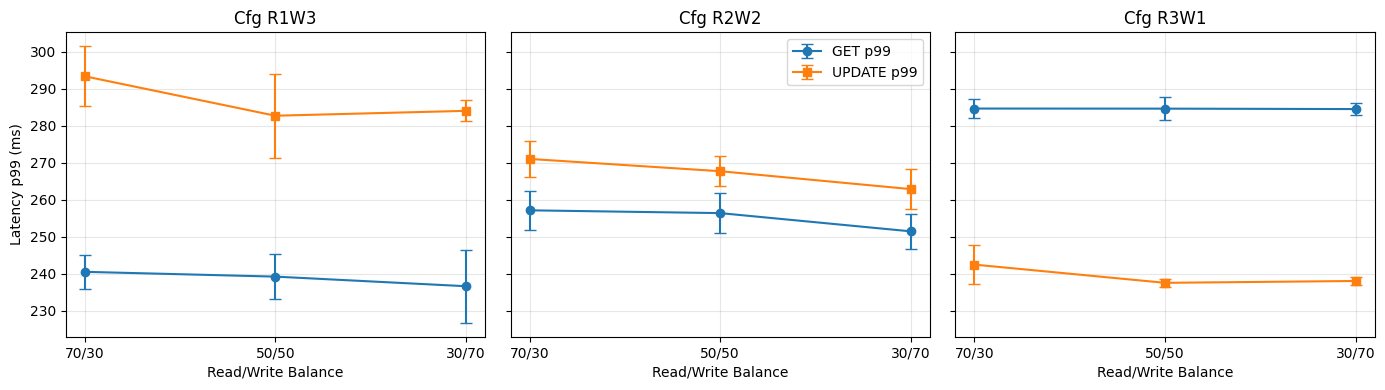

In [26]:
# ============================================================
# 1) PLUG YOUR DATA HERE
# ============================================================
# Structure:
# PLOT_DATA[config_name][mix_label]["GET"]    = (point, lo, hi)
# PLOT_DATA[config_name][mix_label]["UPDATE"] = (point, lo, hi)
#
# point/lo/hi should be your p99 latency (ms) estimates + CI bounds.
#
# Example with fake numbers (replace with yours):
PLOT_DATA = {
    "Cfg R1W3": {
        "70/30": {"GET": final_stats["R1W3"]["p99_read_ms"]["median"],
        "UPDATE": final_stats["R1W3"]["p99_write_ms"]["median"]},
        "50/50": {"GET": final_stats["BalancedR1W3"]["p99_read_ms"]["median"],
        "UPDATE": final_stats["BalancedR1W3"]["p99_write_ms"]["median"]},
        "30/70": {"GET": final_stats["WriteR1W3"]["p99_read_ms"]["median"],
        "UPDATE": final_stats["WriteR1W3"]["p99_write_ms"]["median"]},
    },
    "Cfg R2W2": {
        "70/30": {"GET": final_stats["R2W2"]["p99_read_ms"]["median"],
        "UPDATE": final_stats["R2W2"]["p99_write_ms"]["median"]},
        "50/50": {"GET": final_stats["BalancedR2W2"]["p99_read_ms"]["median"],
        "UPDATE": final_stats["BalancedR2W2"]["p99_write_ms"]["median"]},
        "30/70": {"GET": final_stats["WriteR2W2"]["p99_read_ms"]["median"],
        "UPDATE": final_stats["WriteR2W2"]["p99_write_ms"]["median"]},
    },
    "Cfg R3W1": {
        "70/30": {"GET": final_stats["R3W1"]["p99_read_ms"]["median"],
        "UPDATE": final_stats["R3W1"]["p99_write_ms"]["median"]},
        "50/50": {"GET": final_stats["BalancedR3W1"]["p99_read_ms"]["median"],
        "UPDATE": final_stats["BalancedR3W1"]["p99_write_ms"]["median"]},
        "30/70": {"GET": final_stats["WriteR3W1"]["p99_read_ms"]["median"],
        "UPDATE": final_stats["WriteR3W1"]["p99_write_ms"]["median"]},
    },
}


# This controls x-axis order and labels (must match keys used above)
MIX_ORDER = ["70/30", "50/50", "30/70"]

# ============================================================
# 2) PLOT FUNCTION (no edits needed)
# ============================================================
def _halfwidth(point, lo, hi):
    # symmetric errorbar half-width (matplotlib wants yerr as a distance)
    return max(point - lo, hi - point)

def plot_tail_latency_panels(plot_data: dict, mix_order: list[str]):
    configs = list(plot_data.keys())
    n_cfg = len(configs)

    fig, axes = plt.subplots(1, n_cfg, figsize=(14, 4), sharey=True)
    if n_cfg == 1:
        axes = [axes]

    x = np.arange(len(mix_order))

    for ax, cfg in zip(axes, configs):
        get_y, get_e = [], []
        upd_y, upd_e = [], []

        for mix in mix_order:
            g_pt, g_lo, g_hi = plot_data[cfg][mix]["GET"]
            u_pt, u_lo, u_hi = plot_data[cfg][mix]["UPDATE"]

            get_y.append(g_pt)
            get_e.append(_halfwidth(g_pt, g_lo, g_hi))

            upd_y.append(u_pt)
            upd_e.append(_halfwidth(u_pt, u_lo, u_hi))

        ax.errorbar(x, get_y, yerr=get_e, marker="o", capsize=4, label="GET p99")
        ax.errorbar(x, upd_y, yerr=upd_e, marker="s", capsize=4, label="UPDATE p99")

        ax.set_title(cfg)
        ax.set_xticks(x, mix_order)
        ax.set_xlabel("Read/Write Balance")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Latency p99 (ms)")
    axes[1].legend(loc="upper right")
    # fig.suptitle("Tail latency vs operation mix (3 panels = 3 configurations)")
    fig.tight_layout()
    plt.savefig("quorum_p99.png")  # Saves the current figure as PNG
    plt.show()

# ============================================================
# 3) CALL IT
# ============================================================
plot_tail_latency_panels(PLOT_DATA, MIX_ORDER)

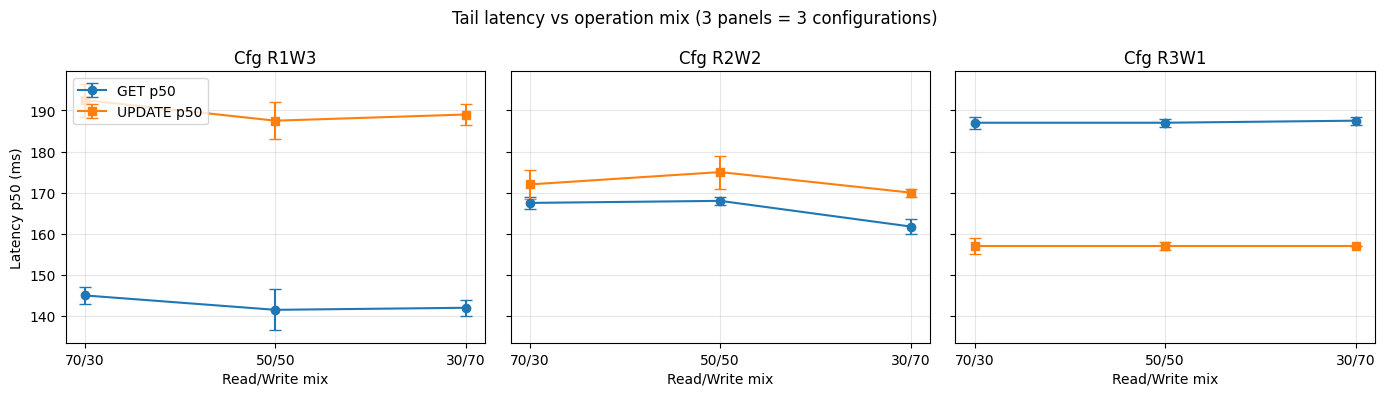

In [ ]:
# ============================================================
# 1) PLUG YOUR DATA HERE
# ============================================================
# Structure:
# PLOT_DATA[config_name][mix_label]["GET"]    = (point, lo, hi)
# PLOT_DATA[config_name][mix_label]["UPDATE"] = (point, lo, hi)
#
# point/lo/hi should be your p99 latency (ms) estimates + CI bounds.
#
# Example with fake numbers (replace with yours):
PLOT_DATA = {
    "Cfg R1W3": {
        "70/30": {"GET": final_stats["R1W3"]["p50_read_ms"]["median"],
        "UPDATE": final_stats["R1W3"]["p50_write_ms"]["median"]},
        "50/50": {"GET": final_stats["BalancedR1W3"]["p50_read_ms"]["median"],
        "UPDATE": final_stats["BalancedR1W3"]["p50_write_ms"]["median"]},
        "30/70": {"GET": final_stats["WriteR1W3"]["p50_read_ms"]["median"],
        "UPDATE": final_stats["WriteR1W3"]["p50_write_ms"]["median"]},
    },
    "Cfg R2W2": {
        "70/30": {"GET": final_stats["R2W2"]["p50_read_ms"]["median"],
        "UPDATE": final_stats["R2W2"]["p50_write_ms"]["median"]},
        "50/50": {"GET": final_stats["BalancedR2W2"]["p50_read_ms"]["median"],
        "UPDATE": final_stats["BalancedR2W2"]["p50_write_ms"]["median"]},
        "30/70": {"GET": final_stats["WriteR2W2"]["p50_read_ms"]["median"],
        "UPDATE": final_stats["WriteR2W2"]["p50_write_ms"]["median"]},
    },
    "Cfg R3W1": {
        "70/30": {"GET": final_stats["R3W1"]["p50_read_ms"]["median"],
        "UPDATE": final_stats["R3W1"]["p50_write_ms"]["median"]},
        "50/50": {"GET": final_stats["BalancedR3W1"]["p50_read_ms"]["median"],
        "UPDATE": final_stats["BalancedR3W1"]["p50_write_ms"]["median"]},
        "30/70": {"GET": final_stats["WriteR3W1"]["p50_read_ms"]["median"],
        "UPDATE": final_stats["WriteR3W1"]["p50_write_ms"]["median"]},
    },
}

# This controls x-axis order and labels (must match keys used above)
MIX_ORDER = ["70/30", "50/50", "30/70"]

# ============================================================
# 2) PLOT FUNCTION (no edits needed)
# ============================================================
def _halfwidth(point, lo, hi):
    # symmetric errorbar half-width (matplotlib wants yerr as a distance)
    return max(point - lo, hi - point)

def plot_tail_latency_panels(plot_data: dict, mix_order: list[str]):
    configs = list(plot_data.keys())
    n_cfg = len(configs)

    fig, axes = plt.subplots(1, n_cfg, figsize=(14, 4), sharey=True)
    if n_cfg == 1:
        axes = [axes]

    x = np.arange(len(mix_order))

    for ax, cfg in zip(axes, configs):
        get_y, get_e = [], []
        upd_y, upd_e = [], []

        for mix in mix_order:
            g_pt, g_lo, g_hi = plot_data[cfg][mix]["GET"]
            u_pt, u_lo, u_hi = plot_data[cfg][mix]["UPDATE"]

            get_y.append(g_pt)
            get_e.append(_halfwidth(g_pt, g_lo, g_hi))

            upd_y.append(u_pt)
            upd_e.append(_halfwidth(u_pt, u_lo, u_hi))

        ax.errorbar(x, get_y, yerr=get_e, marker="o", capsize=4, label="GET p50")
        ax.errorbar(x, upd_y, yerr=upd_e, marker="s", capsize=4, label="UPDATE p50")

        ax.set_title(cfg)
        ax.set_xticks(x, mix_order)
        ax.set_xlabel("Read/Write mix")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Latency p50 (ms)")
    axes[0].legend(loc="upper left")
    fig.suptitle("Tail latency vs operation mix (3 panels = 3 configurations)")
    fig.tight_layout()
    plt.show()

# ============================================================
# 3) CALL IT
# ============================================================
plot_tail_latency_panels(PLOT_DATA, MIX_ORDER)

(0.911406172596228, 0.9070059179271825, 0.9158064272652735)


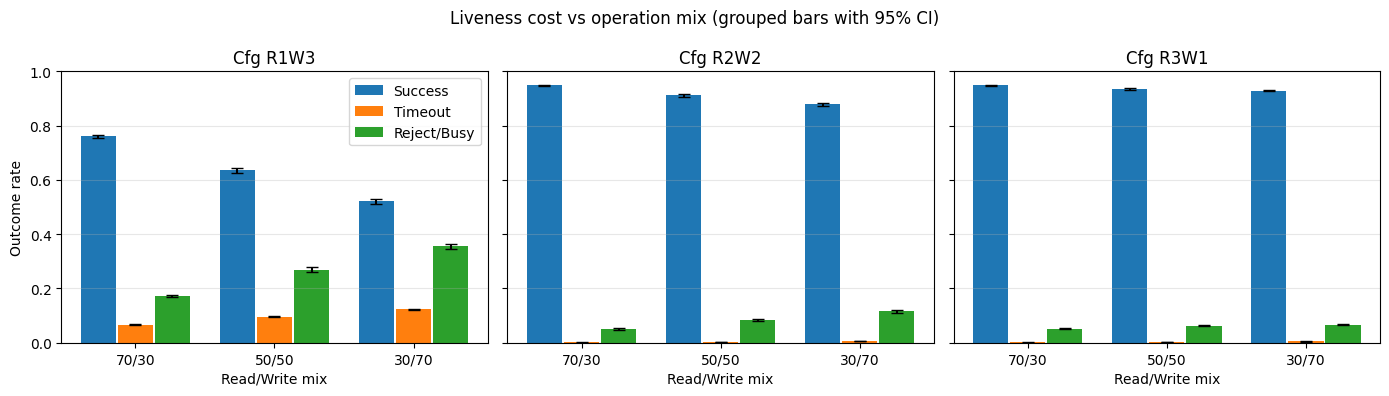

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
print(final_stats["BalancedR2W2"]["success_rate"]["mean"])
BAR_DATA_TUPLES = {
  "Cfg R1W3": {
    "70/30": {
      "success": final_stats["R1W3"]["success_rate"]["mean"],
      "timeout": final_stats["R1W3"]["timeout_rate"]["mean"],
      "busy":    final_stats["R1W3"]["busy_rate"]["mean"],
    },
    "50/50": {
      "success": final_stats["BalancedR1W3"]["success_rate"]["mean"],
      "timeout": final_stats["BalancedR1W3"]["timeout_rate"]["mean"],
      "busy":    final_stats["BalancedR1W3"]["busy_rate"]["mean"],
    },
    "30/70": {
      "success": final_stats["WriteR1W3"]["success_rate"]["mean"],
      "timeout": final_stats["WriteR1W3"]["timeout_rate"]["mean"],
      "busy":    final_stats["WriteR1W3"]["busy_rate"]["mean"],
    },
  },
  "Cfg R2W2": {
    "70/30": {
      "success": final_stats["R2W2"]["success_rate"]["mean"],
      "timeout": final_stats["R2W2"]["timeout_rate"]["mean"],
      "busy":    final_stats["R2W2"]["busy_rate"]["mean"],
    },
    "50/50": {
      "success": final_stats["BalancedR2W2"]["success_rate"]["mean"],
      "timeout": final_stats["BalancedR2W2"]["timeout_rate"]["mean"],
      "busy":    final_stats["BalancedR2W2"]["busy_rate"]["mean"],
    },
    "30/70": {
      "success": final_stats["WriteR2W2"]["success_rate"]["mean"],
      "timeout": final_stats["WriteR2W2"]["timeout_rate"]["mean"],
      "busy":    final_stats["WriteR2W2"]["busy_rate"]["mean"],
    },
  },
  "Cfg R3W1": {
    "70/30": {
      "success": final_stats["R3W1"]["success_rate"]["mean"],
      "timeout": final_stats["R3W1"]["timeout_rate"]["mean"],
      "busy":    final_stats["R3W1"]["busy_rate"]["mean"],
    },
    "50/50": {
      "success": final_stats["BalancedR3W1"]["success_rate"]["mean"],
      "timeout": final_stats["BalancedR3W1"]["timeout_rate"]["mean"],
      "busy":    final_stats["BalancedR3W1"]["busy_rate"]["mean"],
    },
    "30/70": {
      "success": final_stats["WriteR3W1"]["success_rate"]["mean"],
      "timeout": final_stats["WriteR3W1"]["timeout_rate"]["mean"],
      "busy":    final_stats["WriteR3W1"]["busy_rate"]["mean"],
    },
  }
}

MIX_ORDER = ["70/30", "50/50", "30/70"]

# Which measures to plot (grouped bars per mix). Order controls legend and left-to-right bars.
MEASURE_ORDER = ["success", "timeout", "busy"]

LABELS = {
    "success": "Success",
    "timeout": "Timeout",
    "busy": "Reject/Busy",
}

PLOT_AS_PERCENT = False   # set False if your tuples are already percentages

# ============================================================
# 2) PLOT
# ============================================================
def _asymmetric_yerr(point, lo, hi):
    """Matplotlib bar yerr expects distances, not absolute bounds."""
    return (point - lo, hi - point)

def plot_liveness_grouped_bars_with_ci(
    bar_data_tuples: dict,
    mix_order: list[str],
    measure_order: list[str],
    labels: dict[str, str],
    plot_as_percent: bool = True,
):
    configs = list(bar_data_tuples.keys())
    n_cfg = len(configs)

    fig, axes = plt.subplots(1, n_cfg, figsize=(14, 4), sharey=True)
    if n_cfg == 1:
        axes = [axes]

    x = np.arange(len(mix_order))

    # bar geometry: grouped bars around each x
    n_measures = len(measure_order)
    group_width = 0.8
    bar_width = group_width / n_measures
    # centers offsets: e.g. for 3 measures -> [-w, 0, +w]
    offsets = (np.arange(n_measures) - (n_measures - 1) / 2) * bar_width

    scale = 100.0 if plot_as_percent else 1.0
    y_label = "Outcome rate (%)" if plot_as_percent else "Outcome rate"

    for ax, cfg in zip(axes, configs):
        for j, meas in enumerate(measure_order):
            pts = []
            yerr_lo = []
            yerr_hi = []

            for mix in mix_order:
                triple = bar_data_tuples[cfg].get(mix, {}).get(meas, None)

                if triple is None:
                    # if missing, plot 0 with no CI
                    pt, lo, hi = 0.0, 0.0, 0.0
                else:
                    pt, lo, hi = triple

                pt *= scale
                lo *= scale
                hi *= scale

                pts.append(pt)
                dlo, dhi = _asymmetric_yerr(pt, lo, hi)
                yerr_lo.append(dlo)
                yerr_hi.append(dhi)

            pts = np.array(pts, dtype=float)
            yerr = np.vstack([yerr_lo, yerr_hi])  # shape (2, n)

            ax.bar(
                x + offsets[j],
                pts,
                width=bar_width * 0.95,
                yerr=yerr,
                capsize=4,
                label=labels.get(meas, meas),
            )

        ax.set_title(cfg)
        ax.set_xticks(x, mix_order)
        ax.set_xlabel("Read/Write mix")
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_ylim(0,1)

        if plot_as_percent:
            ax.set_ylim(0, 100)

    axes[0].set_ylabel(y_label)
    axes[0].legend(loc="best")
    fig.suptitle("Liveness cost vs operation mix (grouped bars with 95% CI)")
    fig.tight_layout()
    plt.show()

# ============================================================
# 3) CALL IT
# ============================================================
plot_liveness_grouped_bars_with_ci(
    BAR_DATA_TUPLES,
    MIX_ORDER,
    MEASURE_ORDER,
    LABELS,
    plot_as_percent=PLOT_AS_PERCENT,
)

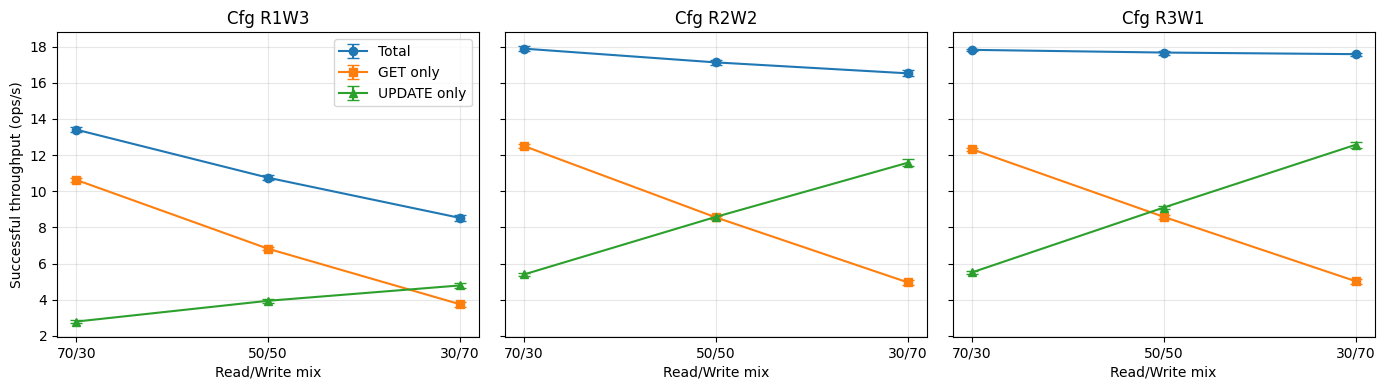

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# throughput_ops_per_s
# throughput_read_ops_per_s
# throughput_write_ops_per_s
# ============================================================
THR3_DATA = {
    "Cfg R1W3": {
        "70/30": {"total": final_stats["R1W3"]["throughput_ops_per_s"]["mean"],
            "read": final_stats["R1W3"]["throughput_read_ops_per_s"]["mean"],
            "write": final_stats["R1W3"]["throughput_write_ops_per_s"]["mean"]},
        "50/50": {"total": final_stats["BalancedR1W3"]["throughput_ops_per_s"]["mean"], 
            "read": final_stats["BalancedR1W3"]["throughput_read_ops_per_s"]["mean"], 
            "write": final_stats["BalancedR1W3"]["throughput_write_ops_per_s"]["mean"]},
        "30/70": {"total": final_stats["WriteR1W3"]["throughput_ops_per_s"]["mean"],
            "read": final_stats["WriteR1W3"]["throughput_read_ops_per_s"]["mean"], 
            "write": final_stats["WriteR1W3"]["throughput_write_ops_per_s"]["mean"]},
    },
    "Cfg R2W2": {
        "70/30": {"total": final_stats["R2W2"]["throughput_ops_per_s"]["mean"],
            "read": final_stats["R2W2"]["throughput_read_ops_per_s"]["mean"],
            "write": final_stats["R2W2"]["throughput_write_ops_per_s"]["mean"]},
        "50/50": {"total": final_stats["BalancedR2W2"]["throughput_ops_per_s"]["mean"],
            "read": final_stats["BalancedR2W2"]["throughput_read_ops_per_s"]["mean"], 
            "write": final_stats["BalancedR2W2"]["throughput_write_ops_per_s"]["mean"]},
        "30/70": {"total": final_stats["WriteR2W2"]["throughput_ops_per_s"]["mean"],
            "read": final_stats["WriteR2W2"]["throughput_read_ops_per_s"]["mean"], 
            "write": final_stats["WriteR2W2"]["throughput_write_ops_per_s"]["mean"]},
    },
    "Cfg R3W1": {
        "70/30": {"total": final_stats["R3W1"]["throughput_ops_per_s"]["mean"], 
            "read": final_stats["R3W1"]["throughput_read_ops_per_s"]["mean"],
            "write": final_stats["R3W1"]["throughput_write_ops_per_s"]["mean"]},
        "50/50": {"total": final_stats["BalancedR3W1"]["throughput_ops_per_s"]["mean"],
            "read": final_stats["BalancedR3W1"]["throughput_read_ops_per_s"]["mean"], 
            "write": final_stats["BalancedR3W1"]["throughput_write_ops_per_s"]["mean"]},
        "30/70": {"total": final_stats["WriteR3W1"]["throughput_ops_per_s"]["mean"],
            "read": final_stats["WriteR3W1"]["throughput_read_ops_per_s"]["mean"], 
            "write": final_stats["WriteR3W1"]["throughput_write_ops_per_s"]["mean"]},
    },
}

MIX_ORDER = ["70/30", "50/50", "30/70"]

# ============================================================
# 2) PLOT (no edits needed)
# ============================================================
def _halfwidth(point, lo, hi):
    return max(point - lo, hi - point)

def plot_throughput_three_panels_total_read_write(thr3_data: dict, mix_order: list[str]):
    configs = list(thr3_data.keys())
    fig, axes = plt.subplots(1, len(configs), figsize=(14, 4), sharey=True)
    if len(configs) == 1:
        axes = [axes]

    x = np.arange(len(mix_order))

    # Small horizontal offsets so the three series don't overlap perfectly
    offsets = {"total": 0.0, "read": -0.03, "write": 0.03}
    markers = {"total": "o", "read": "s", "write": "^"}
    labels  = {"total": "Total", "read": "GET only", "write": "UPDATE only"}

    for ax, cfg in zip(axes, configs):
        for series in ["total", "read", "write"]:
            y, yerr = [], []
            for mix in mix_order:
                pt, lo, hi = thr3_data[cfg][mix][series]
                y.append(pt)
                yerr.append(_halfwidth(pt, lo, hi))

            ax.errorbar(
                x,# + offsets[series],
                y,
                yerr=yerr,
                marker=markers[series],
                capsize=4,
                label=labels[series],
            )

        ax.set_title(cfg)
        ax.set_xticks(x, mix_order)
        ax.set_xlabel("Read/Write mix")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Successful throughput (ops/s)")
    axes[0].legend(loc="best")
    # fig.suptitle("Throughput vs operation mix (Total vs GET vs UPDATE)")
    fig.tight_layout()
    plt.savefig("quorum_t.png")  # Saves the current figure as PNG
    plt.show()

# ============================================================
# 3) CALL IT
# ============================================================
plot_throughput_three_panels_total_read_write(THR3_DATA, MIX_ORDER)